# Minimise a function using `line_search` and `minimize` from `scipy`

In [1]:
import sys
assert sys.version_info >= (3, 7)
import numpy as np
import scipy
from scipy.optimize import line_search, minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set seed for reproducibility
np.random.seed(42)

In [2]:
def objective_func(x):
    """
    Objective function to minimise, which is 
    a polynomial in three variables. 
    
    """
    
    return x[0]**2 + 2*x[1]**2 + 2*x[2]**2 + 2*x[0]*x[1] + 2*x[2]*x[1]

def objective_grad(x):
    """
    Gradient of the objective function.
    Specifically vector of partial derivatives of the objective function, 
    required for gradient-based optimisation.
    
    """
    
    return np.array([2*x[0] + 2*x[1], 4*x[1] + 2*x[0] + 2*x[2], 4*x[2] + 2*x[1]])

# The starting point could be anything, lets set 3 random points since the function has 3 dimensions
starting_point = np.random.rand(3)
starting_point_zero = np.array([0.0, 0.0, 0.0]) # alternative starting point
print("Starting point:", starting_point)

# Set a descending direction
search_gradient_direction = np.array([-1.0, -1.0, -1.0])
search_gradient_direction_zero = np.array([-0, -0, -0])

Starting point: [0.37454012 0.95071431 0.73199394]


In [3]:
line_search(objective_func, objective_grad, starting_point, search_gradient_direction)

(1.0,
 2,
 1,
 0.6277828936074565,
 5.123621471144666,
 array([-1.34949115, -1.98407465, -1.17059562]))

The line search method efficiently finds a suitable step size to minimize the objective along a given descent direction.

In [4]:
line_search(objective_func, objective_grad, starting_point_zero, search_gradient_direction_zero)

(1.0, 2, 1, 0.0, 0.0, array([0., 0., 0.]))

Each starting point converges to a minimum with an optimal step size of `1.0` in only a `2` steps. However, the final positions differ, illustrating dependence on initial conditions. This may suggest multiple stationary points, which is possible, since the function is a 3-degree polynomial.

Before going further, it is worth plotting the function to investigate its shape.

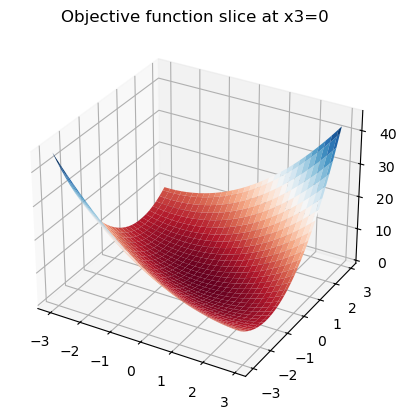

In [5]:
x1 = np.arange(-3.0, 3.0, 0.1)
x2 = np.arange(-3.0, 3.0, 0.1)
X1, X2 = np.meshgrid(x1, x2)
Z = objective_func([X1, X2, np.zeros_like(X1)])  # setting x3 to 0 for 2D slice

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X1, X2, Z, cmap="RdBu")
ax.set_title("Objective function slice at x3=0")
plt.show()


By looking at the plot, the 2D representation of the function looks quadratic (So it may look cubic if plot in 3D). The 2D slice of the function suggests convexity, indicating a single global minimum. However, a full 3D visualization might reveal multiple stationary points and local minima.

Lets try solving with other methods.

In [6]:
minimize(objective_func, starting_point, method="BFGS")

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.1819904524047979e-16
        x: [-7.180e-09  9.391e-10 -6.747e-09]
      nit: 5
      jac: [ 2.419e-09  5.705e-09  4.693e-09]
 hess_inv: [[ 1.500e+00 -1.000e+00  5.000e-01]
            [-1.000e+00  1.000e+00 -5.000e-01]
            [ 5.000e-01 -5.000e-01  5.000e-01]]
     nfev: 28
     njev: 7

In [7]:
minimize(objective_func, starting_point_zero, method="BFGS")

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.0
        x: [ 0.000e+00  0.000e+00  0.000e+00]
      nit: 0
      jac: [ 1.490e-08  2.980e-08  2.980e-08]
 hess_inv: [[1 0 0]
            [0 1 0]
            [0 0 1]]
     nfev: 4
     njev: 1

In [8]:
minimize(objective_func, starting_point, method="Powell")

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 2.724483417540814e-35
       x: [-1.452e-18  3.739e-18  8.715e-19]
     nit: 11
   direc: [[ 2.455e-03 -4.621e-03  1.215e-03]
           [ 2.002e-02 -1.162e-02  9.759e-03]
           [ 1.307e-03  5.789e-05 -1.438e-03]]
    nfev: 364

In [9]:
minimize(objective_func, starting_point_zero, method="Powell")

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 0.0
       x: [ 0.000e+00  0.000e+00  0.000e+00]
     nit: 1
   direc: [[ 1.000e+00  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00  1.000e+00]]
    nfev: 22

It is worth noticing that the function can be minimised with each method and different starting points. However, the search reaches a global minima of `[0.000e+00  0.000e+00  0.000e+00]` and gets stuck in a local minima with a different starting point.